In [1]:
!pip install -q "trl==1.4.0" peft bitsandbytes accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import torch, os, gc
import numpy as np, pandas as pd
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, EarlyStoppingCallback)
from peft import (LoraConfig, get_peft_model,
                  prepare_model_for_kbit_training, TaskType)
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

try: del model, trainer
except: pass
gc.collect(); torch.cuda.empty_cache()

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# >>> Diğer modeller için SADECE bu iki satırı değiştir <
MODEL_ID  = "HuggingFaceTB/SmolLM2-360M-Instruct"
MODEL_KEY = "smollm2"

OUTPUT_DIR = f"/content/drive/MyDrive/bdm_proje/models/{MODEL_KEY}_qlora"
os.makedirs(OUTPUT_DIR, exist_ok=True)
LABEL_NAMES = {0:"Yardım Talebi",1:"Kayıp Bildirimi",2:"Altyapı Hasarı",
               3:"Bağış/Koordinasyon",4:"Diğer/İlgisiz"}

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def make_instruction(tweet):
    return ("Sen bir deprem acil durum sınıflandırma asistanısın. "
            "Verilen tweeti aşağıdaki kategorilerden birine koy. "
            "SADECE kategori adını yaz, başka hiçbir şey yazma.\n\n"
            f"Tweet: {tweet}\n\n"
            "Kategoriler:\n- Yardım Talebi\n- Kayıp Bildirimi\n- Altyapı Hasarı\n"
            "- Bağış/Koordinasyon\n- Diğer/İlgisiz")

def to_pc(df):
    rows = []
    for _, r in df.iterrows():
        msgs = [{"role":"user","content":make_instruction(r['tweet'])}]
        prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        rows.append({"prompt": prompt, "completion": LABEL_NAMES[int(r['label_id'])]})
    return Dataset.from_list(rows)

train_df = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/val.csv')
train_dataset = to_pc(train_df)
val_dataset   = to_pc(val_df)
print("Örnek prompt:\n", train_dataset[0]['prompt'][:300], "\n→", train_dataset[0]['completion'])

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto", dtype=torch.bfloat16,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj","v_proj","k_proj","o_proj"],
    lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM,
))
model.print_trainable_parameters()

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR, num_train_epochs=3,
    per_device_train_batch_size=4, per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4, weight_decay=0.01, warmup_ratio=0.03, lr_scheduler_type="cosine",
    eval_strategy="steps", eval_steps=50, save_strategy="steps", save_steps=50,
    save_total_limit=2, load_best_model_at_end=True, metric_for_best_model="eval_loss",
    logging_steps=10, report_to="none", completion_only_loss=True, seed=SEED,
    fp16=False, bf16=True,
)
trainer = SFTTrainer(model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
    args=sft_config, processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])

torch.cuda.reset_peak_memory_stats()
print("Eğitim başlıyor...\n")
train_result = trainer.train()
train_runtime_s = train_result.metrics['train_runtime']
gpu_mem_gb = torch.cuda.max_memory_allocated() / 1e9
print(f"\n✅ Tamamlandı! Loss={train_result.training_loss:.4f} | "
      f"Süre={train_runtime_s:.0f}s | Peak GPU={gpu_mem_gb:.2f}GB")
trainer.save_model(OUTPUT_DIR); tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✅ Adaptör kaydedildi: {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

Adding EOS to eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

Eğitim başlıyor...



Step,Training Loss,Validation Loss
50,0.128871,0.123094
100,0.084999,0.089281



✅ Tamamlandı! Loss=0.2771 | Süre=696s | Peak GPU=1.81GB
✅ Adaptör kaydedildi: /content/drive/MyDrive/bdm_proje/models/smollm2_qlora


SmolLM2-360M — QLoRA FINE-TUNED SONUÇLARI
Accuracy    : 0.6625  (66.2%)
Macro-F1    : 0.5882
Weighted-F1 : 0.6631
Inference   : 1542.5 ms/tweet
Parse fail  : 0/80

                    precision    recall  f1-score   support

     Yardım Talebi       0.81      0.90      0.85        29
   Kayıp Bildirimi       0.36      0.40      0.38        10
    Altyapı Hasarı       0.71      0.50      0.59        10
Bağış/Koordinasyon       0.38      0.45      0.42        11
     Diğer/İlgisiz       0.76      0.65      0.70        20

          accuracy                           0.66        80
         macro avg       0.61      0.58      0.59        80
      weighted avg       0.67      0.66      0.66        80



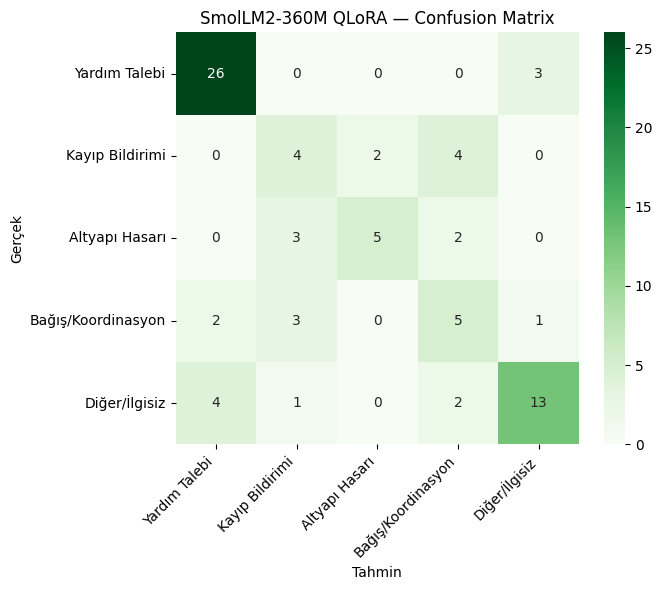


✅ Kaydedildi → /content/drive/MyDrive/bdm_proje/results/fine_tuned


In [5]:
import torch, time, json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

test_df = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/test.csv')
model.config.use_cache = True; model.eval()

def parse_label(text):
    t = text.lower()
    if "yardım" in t or "yardim" in t:                      return 0
    if "kayıp" in t or "kayip" in t:                        return 1
    if "altyapı" in t or "altyapi" in t:                    return 2
    if "bağış" in t or "bagis" in t or "koordinasyon" in t: return 3
    if "diğer" in t or "diger" in t or "ilgisiz" in t:      return 4
    return -1

preds, trues, lat, rows = [], [], [], []
for _, row in test_df.iterrows():
    msgs = [{"role":"user","content":make_instruction(row['tweet'])}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = tokenizer(prompt, return_tensors="pt").to(model.device)
    n = inp['input_ids'].shape[1]
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=12, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id)
    lat.append((time.time()-t0)*1000)
    gen = tokenizer.decode(out[0][n:], skip_special_tokens=True).strip()
    pid = parse_label(gen); pred = pid if pid!=-1 else 4
    g = int(row['label_id']); preds.append(pred); trues.append(g)
    rows.append({'tweet':row['tweet'],'gercek':g,'gercek_ad':LABEL_NAMES[g],
                 'model_yanit':gen,'tahmin':pred,'tahmin_ad':LABEL_NAMES[pred],
                 'parse_fail':pid==-1,'dogru_mu':pred==g})

acc = accuracy_score(trues, preds)
mf1 = f1_score(trues, preds, average='macro', zero_division=0)
wf1 = f1_score(trues, preds, average='weighted', zero_division=0)
print("="*55); print("SmolLM2-360M — QLoRA FINE-TUNED SONUÇLARI"); print("="*55)
print(f"Accuracy    : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Macro-F1    : {mf1:.4f}\nWeighted-F1 : {wf1:.4f}")
print(f"Inference   : {np.mean(lat):.1f} ms/tweet")
print(f"Parse fail  : {sum(r['parse_fail'] for r in rows)}/{len(rows)}\n")
print(classification_report(trues, preds, labels=[0,1,2,3,4],
      target_names=[LABEL_NAMES[i] for i in range(5)], zero_division=0))
cm = confusion_matrix(trues, preds, labels=[0,1,2,3,4])

out_dir = '/content/drive/MyDrive/bdm_proje/results/fine_tuned'; os.makedirs(out_dir, exist_ok=True)
sonuc = {"model":"SmolLM2-360M-Instruct","yontem":"QLoRA (4-bit NF4, bf16)","seed":SEED,
    "test_size":int(len(test_df)),"accuracy":round(float(acc),4),"f1_macro":round(float(mf1),4),
    "f1_weighted":round(float(wf1),4),"inference_ms":round(float(np.mean(lat)),1),
    "egitim_suresi_s":round(float(train_runtime_s),0),"peak_gpu_gb":round(float(gpu_mem_gb),2),
    "egitilen_param":int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    "parse_basarisiz":int(sum(r['parse_fail'] for r in rows)),"confusion_matrix":cm.tolist(),
    "classification_report":classification_report(trues,preds,labels=[0,1,2,3,4],
        target_names=[LABEL_NAMES[i] for i in range(5)],zero_division=0,output_dict=True)}
with open(os.path.join(out_dir,'smollm2_qlora_sonuc.json'),'w',encoding='utf-8') as f:
    json.dump(sonuc, f, ensure_ascii=False, indent=2)
pd.DataFrame(rows).query('dogru_mu == False').to_csv(
    os.path.join(out_dir,'smollm2_qlora_hatalar.csv'), index=False, encoding='utf-8')
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[LABEL_NAMES[i] for i in range(5)],
            yticklabels=[LABEL_NAMES[i] for i in range(5)])
plt.xlabel('Tahmin'); plt.ylabel('Gerçek'); plt.title('SmolLM2-360M QLoRA — Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
plt.savefig(os.path.join(out_dir,'smollm2_qlora_cm.png'), dpi=150, bbox_inches='tight'); plt.show()
print(f"\n✅ Kaydedildi → {out_dir}")